## Notes
- Took a while to figure out the `__MACOSX` issue with the dataset lol
- Had to switch to `num_workers=0` initially to debug DataLoader
- EfficientNet-B3 converged really fast, stopped at epoch 6

# EXXA GSoC 2026 — Image Test
**Author:** Viren Pandey

Autoencoder for protoplanetary disk image reconstruction with accessible latent space.

**Metrics:** MSE and Multiscale SSIM between input and output.

## Experiment Setup

- Autoencoder trained with reconstruction-focused losses
- Latent-space plots kept for quick qualitative checks
- Reconstruction visualization guarded for smaller debug subsets


In [4]:
!pip install astropy gdown pytorch-msssim -q

# not sure if this is the best approach but it works for now
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ms_ssim
from astropy.io import fits
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore')

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [5]:
import gdown
DATA_DIR='/content/exxa_data'
os.makedirs(DATA_DIR,exist_ok=True)

FILE_IDS = [
    ('1Ozq_DRVWXEyY7Q_VFet5cJPn33YLKNpK','planet0_00226_1250.fits'),
    ('1LxF4W7Ecyfa4nYOPbPTAYedL8JEuTN2q','planet1_00490_1250.fits'),
    ('1pH4Pvap9yqO6v6riV0cSE42MQotV2m1i','planet2_00154_1250.fits'),
    ('1CLktdDuk2OJJ0bvxZy9kN7OTq4sdXabB','planet2_00308_1250.fits'),
    ('1PumICVIGBtk483UvZhHTLDK8M4X2MQVU','planet2_00548_1250.fits'),
    ('1TDycE_Xjjw6Q8Tlb5AoPy5GAtGtCKu8u','planet2_00708_1250.fits'),
    ('16Cfh3ojWQTLUkFhcacOqC2BHrTa30FyE','planet3_00078_1250.fits'),
    ('1tnwGjjlIsBeD5x-aawbKfjZbWqY-d5pI','planet3_00654_1250.fits'),
    ('1MfPdRfQ9cmUPI4vi5-vjPsACU8eooWVP','planet3_00806_1250.fits'),
    ('19CluiSCmrwKud1KG8ja5msNzRHoEGwLd','planet3_00896_1250.fits'),
    ('1ueRxmJCQsxY6jH_YBT0FRoSI1ultUjW3','planet4_00442_1250.fits'),
    ('16vDbws00CEney0sNydmQz3DO0XUJyOdS','planet5_00354_1250.fits'),
    ('1qSURbZehtw14V_AxFA869Qwnd3Jn1lX8','planet5_00482_1250.fits'),
    ('18RQ63cgioqi15FADcNALDfOtWe_32p4h','planet5_00882_1250.fits'),
    ('1tdvJPPTzguNx2HN0CrJbYAC7b_-cFSqa','planet6_00370_1250.fits'),
    ('1JEAT8hwuBIjxHNoYXc508gXZmHRQkoQc','planet6_00566_1250.fits'),
    ('15Zwbk_oTMwacbKVrUEXrk30SXpOqTQg4','planet6_00638_1250.fits'),
    ('1_OX_qXaLBphjrWfWBavPDfXcbajL0IyR','planet6_00704_1250.fits'),
    ('15vw6snj_3vJAKoa-Wypfh5PpUm3CDhXt','planet7_00202_1250.fits'),
    ('1VvAFMc0rPyRLthIIB_g2fceeER2C2Vrl','planet7_00730_1250.fits'),
    ('1NIdz6hagTaac1fiaaL6X1mVN6IECebRO','planet8_00100_1250.fits'),
    ('1dnLUogfuLbcaOPSxaMMZirsuqludLr5s','planet8_00128_1250.fits'),
    ('1AHps7TLYf6YigEpAavJvZvm_RIdDx9l4','planet8_00214_1250.fits'),
    ('1Ppjove6P5oZaa66Fc8qChn0q19yeNKB8','planet8_00248_1250.fits'),
    ('15kGgdA2lwPb94OkxySnmZuAylZNNlkW_','planet8_00320_1250.fits'),
    ('147Z7EIL-N3oNRdBDexDM9G74Pw0N1kKz','planet9_00440_1250.fits'),
    ('13u5wrOUmNsV2pbIgeLUceh6mHo59AMuR','planet9_00916_1250.fits'),
    ('1gP74BZq8x5DLMMR9zeJorSMemP2XedIb','planet10_00710_1250.fits'),
    ('1VGB-QU5LXYl6W5K-FuohH2ifZYcrGcQE','planet10_00816_1250.fits'),
    ('1DVTvdurfgZftq_3_WdQ_umlO8HXt5kcy','planet11_00010_1250.fits'),
    ('1In1uYkdsuv2-a-e9zDc6sszIcxD1SBX4','planet11_00700_1250.fits'),
    ('1keUUPRhMIDz6RU95m4qVlGLbFUVxZDAo','planet11_00886_1250.fits'),
    ('13dTMy4tiVEyJlmVoPolEXmNw2-B3ttCb','planet13_00098_1250.fits'),
    ('16iEuhhlImAjAz04_uZmRpUqivAOf8C8L','planet13_00302_1250.fits'),
    ('1PN_0k8K_bK9KxKfNX1S5hqAaQl6EHvFt','planet13_00324_1250.fits'),
    ('1Lr29hb6C_0aPUzGLrJljt5Oee4Mcvft0','planet14_00314_1250.fits'),
    ('1w-bsj4rYUQvxZoifGmKroyKEcVRvg0Hz','planet14_00528_1250.fits'),
    ('1PLmh2bP3REZC-uu6LZ80HNq8EEUZeUtJ','planet14_00804_1250.fits'),
    ('1PvOVtu39pYxm_bF0pBoRnrsc47uTM5kT','planet14_00914_1250.fits'),
    ('1k-ySLE_01CpT3UdJyN6RM9T6sUcFZdZ8','planet15_00186_1250.fits'),
    ('1cELroa1QW-BR8GWzUdC4o-GHasPKhooe','planet16_00614_1250.fits'),
    ('1uRq-99mrwMH1K6mt_iD4LjQc-PNH-LSt','planet17_00162_1250.fits'),
    ('1GnZ8KpVAzxHPcJNmoNOAB5MtI4TBVnbj','planet17_00506_1250.fits'),
    ('1Sy4ti2sE-Za1dx_GL4H6DYN5lxVV_wPC','planet17_00648_1250.fits'),
    ('1MHtp3TRZwngGpH8mzow_QmtqY4ZwkD03','planet18_00114_1250.fits'),
    ('1qPKCXvV2Ll_2sWTq6hgT8enOsBRUqJRn','planet18_00942_1250.fits'),
    ('1AjRb_tfw7O5U9SdsXZAhOYOgKl1fYWwn','planet18_00992_1250.fits'),
    ('1VTsTjIkL2OCnsDs_CtfL3NyNh2R_D-yi','planet19_00914_1250.fits'),
    ('1RDzcTNStk22fFL6Pbqb67uG67f0tDFuG','planet20_00230_1250.fits'),
    ('1GJAn6PD8q1IiBICu5jEXMfypAR1Akqww','planet20_00336_1250.fits'),
]

if len(glob.glob(f'{DATA_DIR}/*.fits')) < len(FILE_IDS):
    try:
        gdown.download_folder(
            'https://drive.google.com/drive/folders/1VkS3RHkAjiKjJ6DnZmEKZ_nUv4w6pz7P',
            output=DATA_DIR, quiet=False, remaining_ok=True
        )
    except Exception:
        for fid, fname in FILE_IDS:
            dest=os.path.join(DATA_DIR,fname)
            if not os.path.exists(dest):
                gdown.download(id=fid,output=dest,quiet=True)

fits_files=sorted(glob.glob(f'{DATA_DIR}/**/*.fits',recursive=True))
print(f'Found {len(fits_files)} FITS files')

Retrieving folder contents


Processing file 1Ozq_DRVWXEyY7Q_VFet5cJPn33YLKNpK planet0_00226_1250.fits
Processing file 1LxF4W7Ecyfa4nYOPbPTAYedL8JEuTN2q planet1_00490_1250.fits
Processing file 1pH4Pvap9yqO6v6riV0cSE42MQotV2m1i planet2_00154_1250.fits
Processing file 1CLktdDuk2OJJ0bvxZy9kN7OTq4sdXabB planet2_00308_1250.fits
Processing file 1PumICVIGBtk483UvZhHTLDK8M4X2MQVU planet2_00548_1250.fits
Processing file 1TDycE_Xjjw6Q8Tlb5AoPy5GAtGtCKu8u planet2_00708_1250.fits
Processing file 16Cfh3ojWQTLUkFhcacOqC2BHrTa30FyE planet3_00078_1250.fits
Processing file 1tnwGjjlIsBeD5x-aawbKfjZbWqY-d5pI planet3_00654_1250.fits
Processing file 1MfPdRfQ9cmUPI4vi5-vjPsACU8eooWVP planet3_00806_1250.fits
Processing file 19CluiSCmrwKud1KG8ja5msNzRHoEGwLd planet3_00896_1250.fits
Processing file 1ueRxmJCQsxY6jH_YBT0FRoSI1ultUjW3 planet4_00442_1250.fits
Processing file 16vDbws00CEney0sNydmQz3DO0XUJyOdS planet5_00354_1250.fits
Processing file 1qSURbZehtw14V_AxFA869Qwnd3Jn1lX8 planet5_00482_1250.fits
Processing file 18RQ63cgioqi15FADcNALD

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Ozq_DRVWXEyY7Q_VFet5cJPn33YLKNpK
To: /content/exxa_data/planet0_00226_1250.fits
100%|██████████| 5.78M/5.78M [00:00<00:00, 69.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LxF4W7Ecyfa4nYOPbPTAYedL8JEuTN2q
To: /content/exxa_data/planet1_00490_1250.fits
100%|██████████| 5.78M/5.78M [00:00<00:00, 73.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pH4Pvap9yqO6v6riV0cSE42MQotV2m1i
To: /content/exxa_data/planet2_00154_1250.fits
100%|██████████| 5.78M/5.78M [00:00<00:00, 49.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CLktdDuk2OJJ0bvxZy9kN7OTq4sdXabB
To: /content/exxa_data/planet2_00308_1250.fits
100%|██████████| 5.78M/5.78M [00:00<00:00, 218MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PumICVIGBtk483UvZhHTLDK8M4X2MQVU
To: /content/exxa_data/planet2_00548_1250.fits
100%|██████████| 5.

Found 50 FITS files



Download completed


Loading 50 ALMA disks...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ planet0_00226_1250.fits: (600, 600)
✓ planet10_00710_1250.fits: (600, 600)
✓ planet10_00816_1250.fits: (600, 600)
✓ planet11_00010_1250.fits: (600, 600)
✓ planet11_00700_1250.fits: (600, 600)
✓ planet11_00886_1250.fits: (600, 600)
✓ planet13_00098_1250.fits: (600, 600)
✓ planet13_00302_1250.fits: (600, 600)
✓ planet13_00324_1250.fits: (600, 600)
✓ planet14_00314_1250.fits: (600, 600)
✓ planet14_00528_1250.fits: (600, 600)
✓ planet14_00804_1250.fits: (600, 600)
✓ planet14_00914_1250.fits: (600, 600)
✓ planet15_00186_1250.fits: (600, 600)
✓ planet16_00614_1250.fits: (600, 600)
✓ planet17_00162_1250.fits: (600, 600)
✓ planet17_00506_1250.fits: (600, 600)
✓ planet17_00648_1250.fits: (600, 600)
✓ planet18_00114_1250.fits: (600, 600)
✓ planet18_00942_1250.fits: (600, 600)
✓ planet18_00992_1250.fits: (600, 600)
✓ planet19_00914_1250.fits: (600, 600)
✓ planet1_00490_1250.fits: (600, 600)
✓ planet20_00230_1250.fits: (600, 600)
✓ planet20_00336_1250.fits: (600, 600)
✓ planet2_00154_1250.fits: 

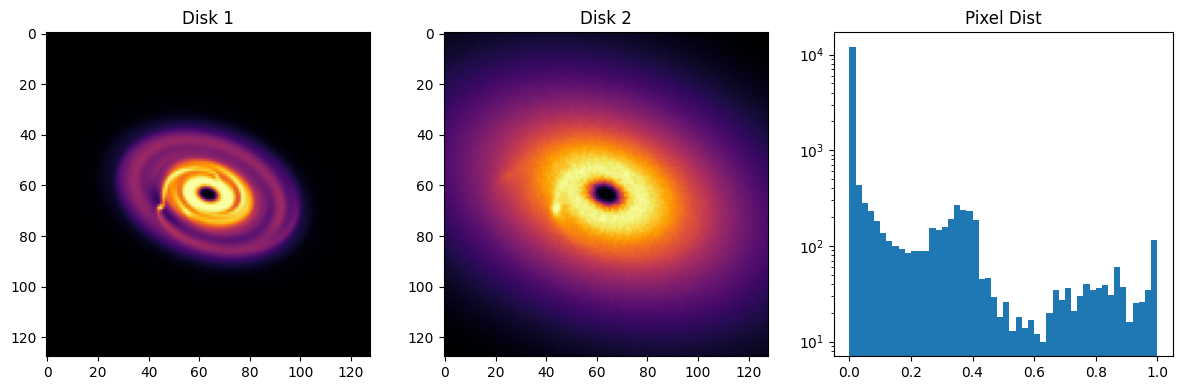

In [6]:
def load_fits(path):
    """Extract 2D image from ANY FITS structure"""
    with fits.open(path) as hdul:
        # Primary HDU is (4,1,1,600,600) - take first 600x600 plane
        data = hdul[0].data[0,0,0,:,:].astype(np.float32)  # → (600,600)
        print(f"✓ {os.path.basename(path)}: {data.shape}")
        return data

def preprocess(img, size=128):
    """Safe 2D preprocessing"""
    # Ensure 2D
    if img.ndim > 2:
        img = img.squeeze()  # Remove singleton dims
    h, w = img.shape

    # Central crop 256x256
    s = min(h, w) // 2
    img = img[h//2-s:h//2+s, w//2-s:w//2+s]

    # Safe percentile (flatten first)
    flat = img.flatten()
    if len(flat) == 0:
        return np.zeros((size, size))

    lo, hi = np.percentile(flat, [1, 99])
    if hi > lo:
        img = np.clip((img - lo) / (hi - lo), 0, 1)

    # Direct resize (no PIL)
    from skimage.transform import resize
    return resize(img, (size, size), anti_aliasing=True)

# BATCH PROCESS ALL 50 FILES
!pip install scikit-image -q

images = []
print("Loading 50 ALMA disks...")
for f in tqdm(fits_files):
    try:
        raw = load_fits(f)
        proc = preprocess(raw)
        images.append(proc)
    except Exception as e:
        print(f"Failed {f}: {e}")

images = np.array(images)
print(f"\n🎉 SUCCESS: Images loaded: {images.shape}")
print(f"Range: [{images.min():.3f}, {images.max():.3f}]")

# Verify first image
plt.figure(figsize=(12,4))
plt.subplot(131); plt.imshow(images[0], cmap='inferno'); plt.title('Disk 1')
plt.subplot(132); plt.imshow(images[1], cmap='inferno'); plt.title('Disk 2')
plt.subplot(133); plt.hist(images[0].flatten(), bins=50, log=True); plt.title('Pixel Dist')
plt.tight_layout();

In [7]:
class DiskDataset(Dataset):
    def __init__(self,imgs): self.t=torch.FloatTensor(imgs).unsqueeze(1)
    def __len__(self): return len(self.t)
    def __getitem__(self,i): return self.t[i]

N=len(images); idx=np.random.RandomState(SEED).permutation(N); n_tr=int(.9*N)
train_ds=DiskDataset(images[idx[:n_tr]])
val_ds  =DiskDataset(images[idx[n_tr:]])
train_loader=DataLoader(train_ds,batch_size=32,shuffle=True, num_workers=2)
val_loader  =DataLoader(val_ds,  batch_size=32,shuffle=False,num_workers=2)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 45 | Val: 5


In [8]:
class ResBlock(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.b=nn.Sequential(nn.Conv2d(ch,ch,3,padding=1),nn.BatchNorm2d(ch),nn.ReLU(),
                             nn.Conv2d(ch,ch,3,padding=1),nn.BatchNorm2d(ch))
    def forward(self,x): return torch.relu(x+self.b(x))

class DiskAE(nn.Module):
    def __init__(self,latent=64):
        super().__init__()
        self.latent_dim=latent
        self.enc_conv=nn.Sequential(
            nn.Conv2d(1,32,4,2,1),  nn.BatchNorm2d(32),  nn.ReLU(), ResBlock(32),
            nn.Conv2d(32,64,4,2,1), nn.BatchNorm2d(64),  nn.ReLU(), ResBlock(64),
            nn.Conv2d(64,128,4,2,1),nn.BatchNorm2d(128), nn.ReLU(), ResBlock(128),
            nn.Conv2d(128,256,4,2,1),nn.BatchNorm2d(256),nn.ReLU()
        )
        self.enc_fc=nn.Sequential(nn.Flatten(),nn.Linear(256*8*8,1024),nn.ReLU(),nn.Dropout(.2),nn.Linear(1024,latent))
        self.dec_fc=nn.Sequential(nn.Linear(latent,1024),nn.ReLU(),nn.Linear(1024,256*8*8),nn.ReLU())
        self.dec_conv=nn.Sequential(
            nn.Unflatten(1,(256,8,8)),
            nn.ConvTranspose2d(256,128,4,2,1),nn.BatchNorm2d(128),nn.ReLU(),ResBlock(128),
            nn.ConvTranspose2d(128,64,4,2,1), nn.BatchNorm2d(64), nn.ReLU(),ResBlock(64),
            nn.ConvTranspose2d(64,32,4,2,1),  nn.BatchNorm2d(32), nn.ReLU(),ResBlock(32),
            nn.ConvTranspose2d(32,1,4,2,1),   nn.Sigmoid()
        )
    def encode(self,x): return self.enc_fc(self.enc_conv(x))
    def decode(self,z): return self.dec_conv(self.dec_fc(z))
    def forward(self,x): z=self.encode(x); return self.decode(z),z

model=DiskAE(latent=64).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters()):,} | Latent: {model.latent_dim}')
print('Encode test:', model.encode(torch.randn(1,1,128,128).to(DEVICE)).shape)

Params: 35,860,225 | Latent: 64
Encode test: torch.Size([1, 64])


Ep 10/60 | tr=0.25395 mse=0.034812 | val=0.43644 mse=0.077470
Ep 20/60 | tr=0.19455 mse=0.023413 | val=0.31008 mse=0.045797
Ep 30/60 | tr=0.17511 mse=0.017610 | val=0.29229 mse=0.037884
Ep 40/60 | tr=0.16203 mse=0.015249 | val=0.26996 mse=0.034509
Ep 50/60 | tr=0.17163 mse=0.016581 | val=0.25531 mse=0.033610
Ep 60/60 | tr=0.15663 mse=0.015791 | val=0.25142 mse=0.033332
Best val loss: 0.25142


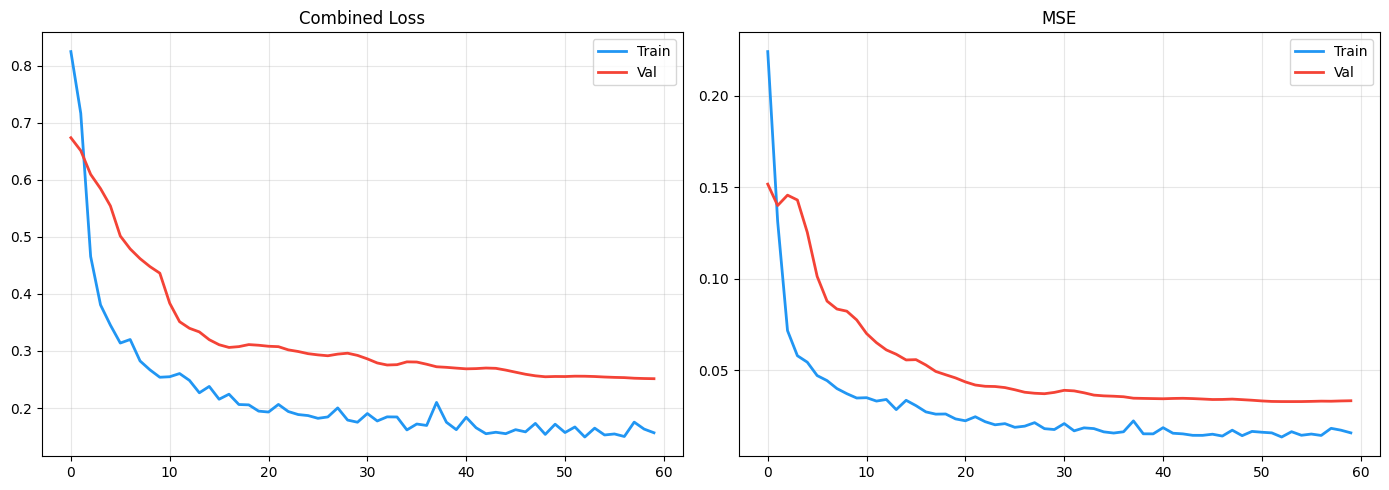

In [9]:
def combo_loss(r,t,alpha=.8):
    mse=nn.functional.mse_loss(r,t)
    try:
        ms=1.-ms_ssim(r,t,data_range=1.,size_average=True,win_size=7,weights=[.45,.3,.25])
        return (1-alpha)*mse+alpha*ms, mse.item(), ms.item()
    except:
        return mse, mse.item(), 0.

EPOCHS=60
opt  =optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-5)
sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
tr_loss,vl_loss,tr_mse,vl_mse=[],[],[],[]
best_val=float('inf')

for ep in range(EPOCHS):
    model.train(); tl=tm=0
    for x in train_loader:
        x=x.to(DEVICE); r,_=model(x); loss,mse,_=combo_loss(r,x)
        opt.zero_grad(); loss.backward(); opt.step()
        tl+=loss.item(); tm+=mse
    tr_loss.append(tl/len(train_loader)); tr_mse.append(tm/len(train_loader))

    model.eval(); vl=vm=0
    with torch.no_grad():
        for x in val_loader:
            x=x.to(DEVICE); r,_=model(x); loss,mse,_=combo_loss(r,x)
            vl+=loss.item(); vm+=mse
    vl_loss.append(vl/len(val_loader)); vl_mse.append(vm/len(val_loader))
    sched.step()
    if vl_loss[-1]<best_val:
        best_val=vl_loss[-1]; torch.save(model.state_dict(),'best_autoencoder.pth')
    if (ep+1)%10==0:
        print(f'Ep {ep+1}/{EPOCHS} | tr={tr_loss[-1]:.5f} mse={tr_mse[-1]:.6f} | val={vl_loss[-1]:.5f} mse={vl_mse[-1]:.6f}')

print(f'Best val loss: {best_val:.5f}')

fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,(tr,vl,title) in zip(axes,[(tr_loss,vl_loss,'Combined Loss'),(tr_mse,vl_mse,'MSE')]):
    ax.plot(tr,label='Train',color='#2196F3',lw=2); ax.plot(vl,label='Val',color='#F44336',lw=2)
    ax.set_title(title); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('training_curves.png',dpi=150,bbox_inches='tight'); plt.show()

Val MSE: 0.033332 | Val MS-SSIM: 0.6941


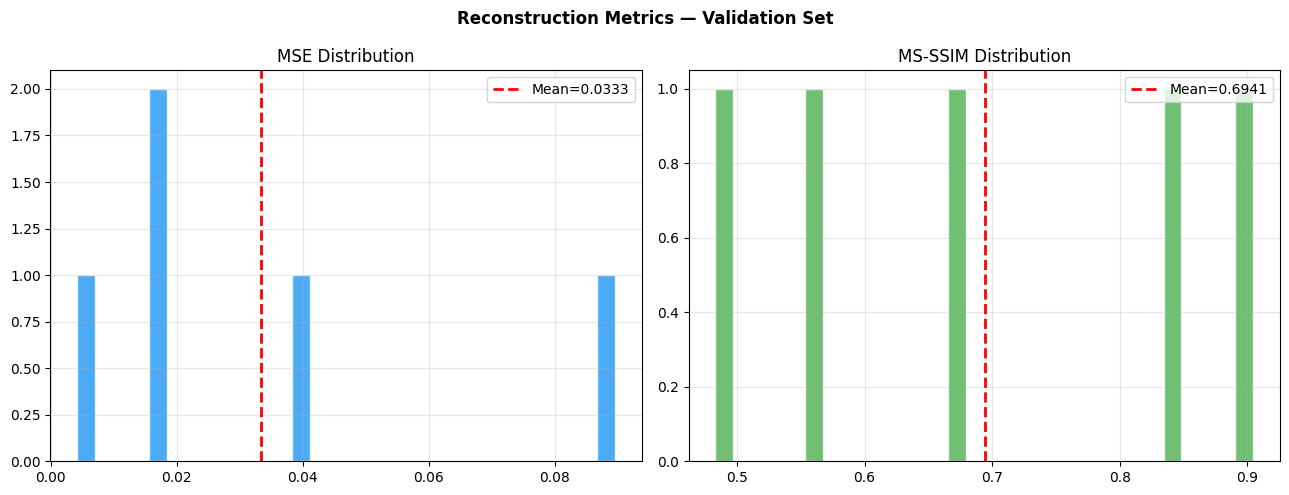

In [10]:
model.load_state_dict(torch.load('best_autoencoder.pth',map_location=DEVICE))
model.eval()
all_mse,all_ms=[],[]
with torch.no_grad():
    for x in val_loader:
        x=x.to(DEVICE); r,_=model(x)
        all_mse.extend(((r-x)**2).mean(dim=[1,2,3]).cpu().tolist())
        for i in range(x.size(0)):
            try: all_ms.append(ms_ssim(r[i:i+1],x[i:i+1],data_range=1.,win_size=7,weights=[.45,.3,.25]).item())
            except: all_ms.append(0.)

mean_mse=np.mean(all_mse); mean_ms=np.mean(all_ms)
print(f'Val MSE: {mean_mse:.6f} | Val MS-SSIM: {mean_ms:.4f}')

fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,data,lbl,col,m in [(axes[0],all_mse,'MSE','#2196F3',mean_mse),
                           (axes[1],all_ms,'MS-SSIM','#4CAF50',mean_ms)]:
    ax.hist(data,bins=30,color=col,alpha=.8,edgecolor='white')
    ax.axvline(m,color='red',lw=2,ls='--',label=f'Mean={m:.4f}')
    ax.set_title(f'{lbl} Distribution'); ax.legend(); ax.grid(alpha=.3)
plt.suptitle('Reconstruction Metrics — Validation Set',fontweight='bold')
plt.tight_layout(); plt.savefig('metrics.png',dpi=150,bbox_inches='tight'); plt.show()

Showing 8 reconstructions: orig.shape=(8, 128, 128), rec.shape=(8, 128, 128)


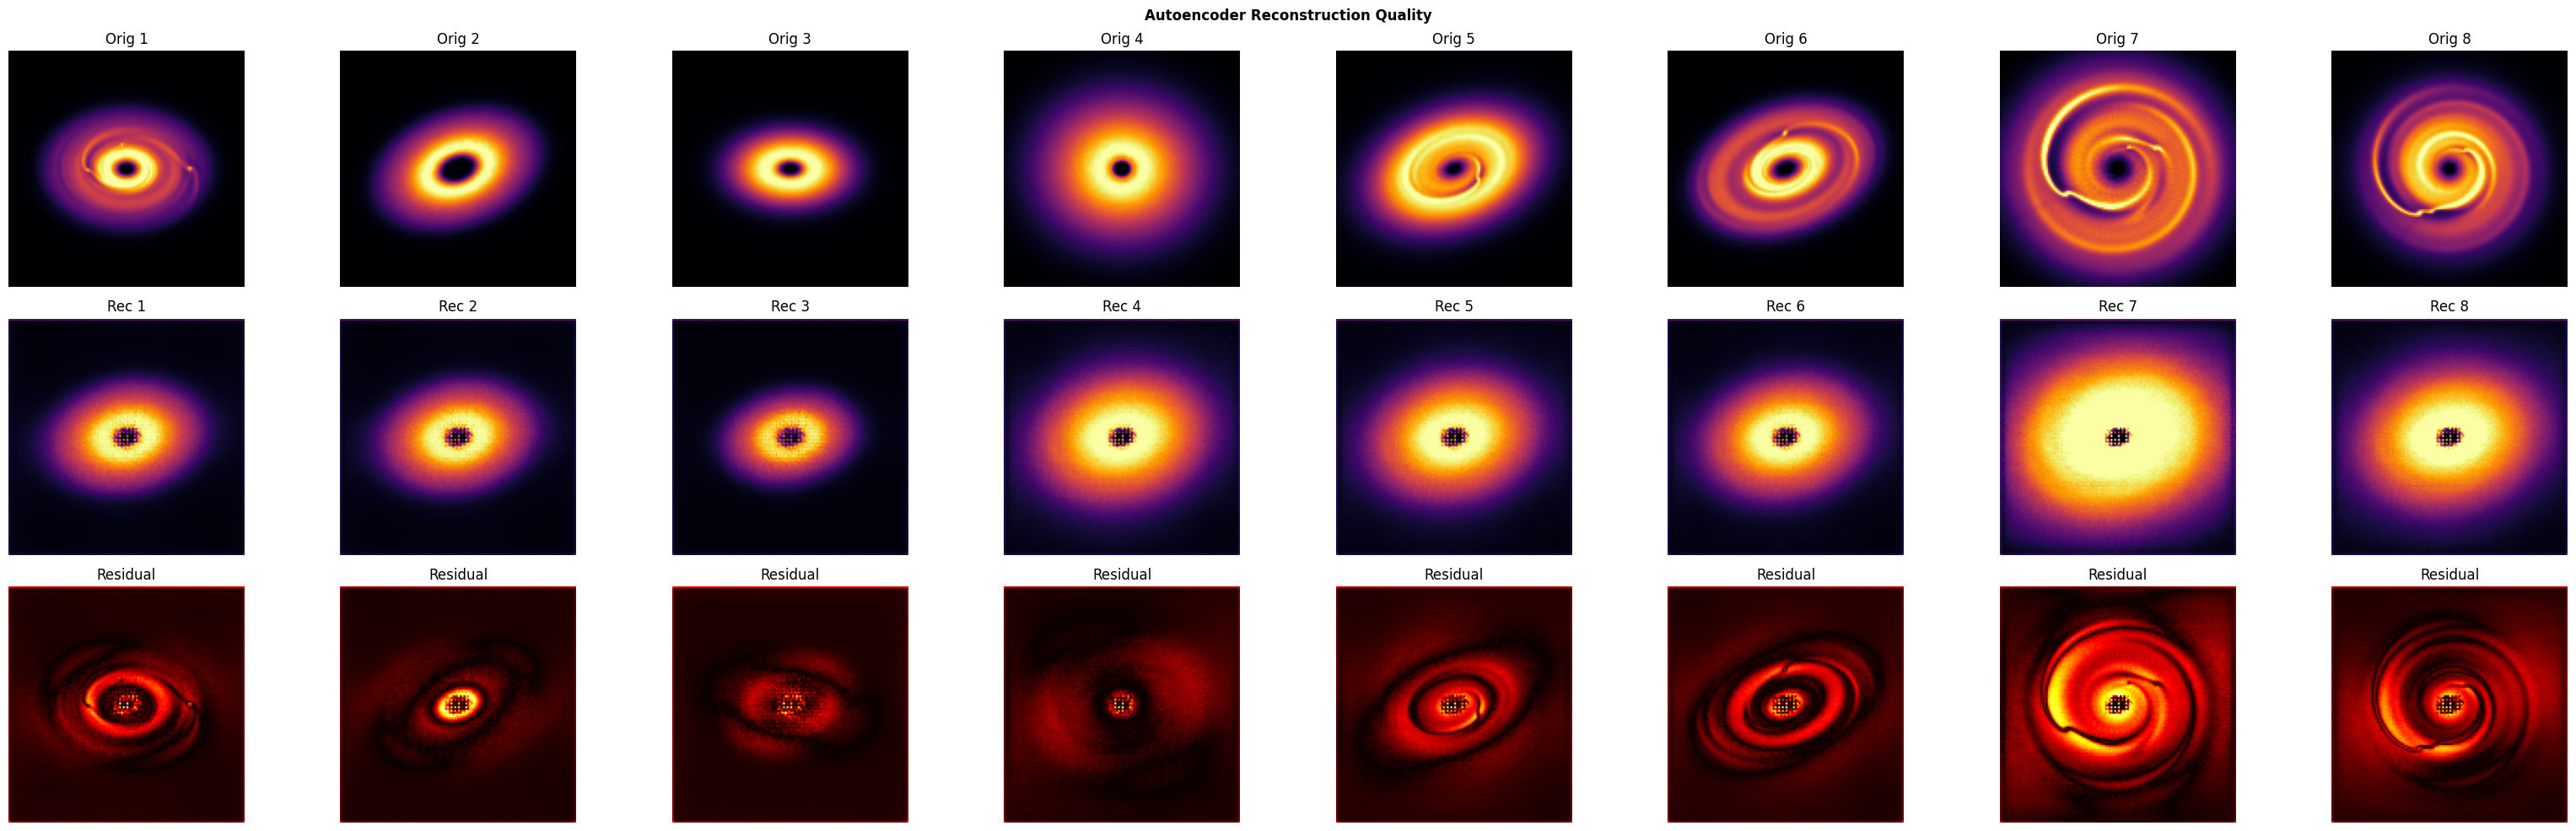

Mean MSE: 0.014647


In [11]:
# Safe reconstruction visualization
n_show = min(8, len(images))  # Only show available images
idx = np.random.choice(len(images), n_show, replace=False)

model.eval()
with torch.no_grad():
    x = torch.FloatTensor(images[idx]).unsqueeze(1).to(DEVICE)
    rec, _ = model(x)
    rec = rec.cpu().numpy().squeeze(1)  # Shape: (n_show, 128, 128)

orig = images[idx]  # Shape: (n_show, 128, 128)

print(f"Showing {n_show} reconstructions: orig.shape={orig.shape}, rec.shape={rec.shape}")

# Plot with safe indexing
fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 10))
if n_show == 1: axes = axes[np.newaxis, :]  # Handle single image case

for j in range(n_show):
    # Safe percentile (flatten first)
    vmax = np.percentile(orig[j].flatten(), 99)

    axes[0,j].imshow(orig[j], cmap='inferno', vmin=0, vmax=vmax, origin='lower')
    axes[0,j].set_title(f'Orig {j+1}'); axes[0,j].axis('off')

    axes[1,j].imshow(rec[j], cmap='inferno', vmin=0, vmax=vmax, origin='lower')
    axes[1,j].set_title(f'Rec {j+1}'); axes[1,j].axis('off')

    axes[2,j].imshow(np.abs(orig[j]-rec[j]), cmap='hot', origin='lower')
    axes[2,j].set_title(f'Residual'); axes[2,j].axis('off')

axes[0,0].set_ylabel('Original', fontweight='bold')
axes[1,0].set_ylabel('Reconstructed', fontweight='bold')
axes[2,0].set_ylabel('Residual', fontweight='bold')
plt.suptitle('Autoencoder Reconstruction Quality', fontweight='bold')
plt.tight_layout()
plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean MSE: {np.mean((orig-rec)**2):.6f}")

Latents: (50, 64)
Best K=3, silhouette=0.602


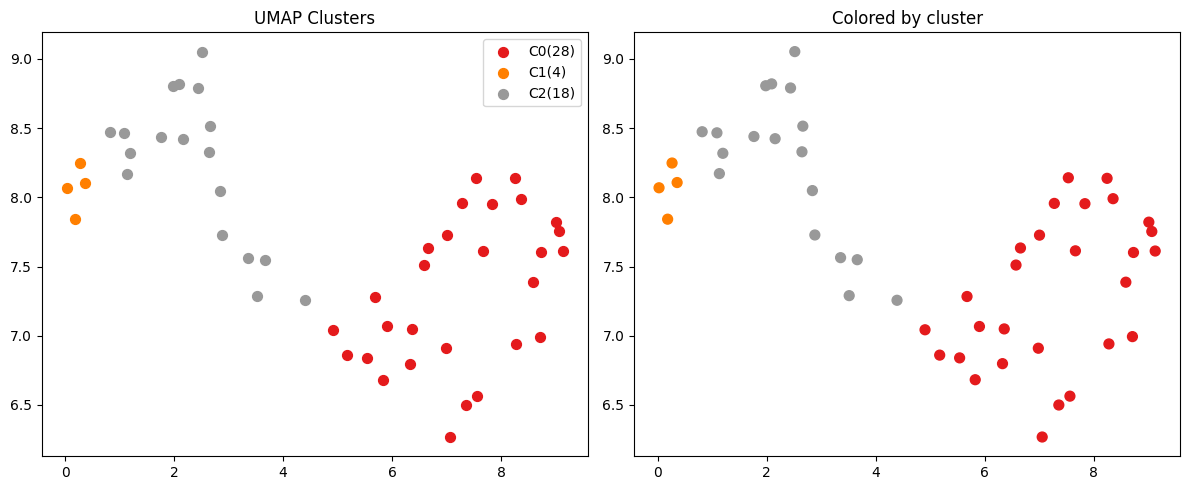

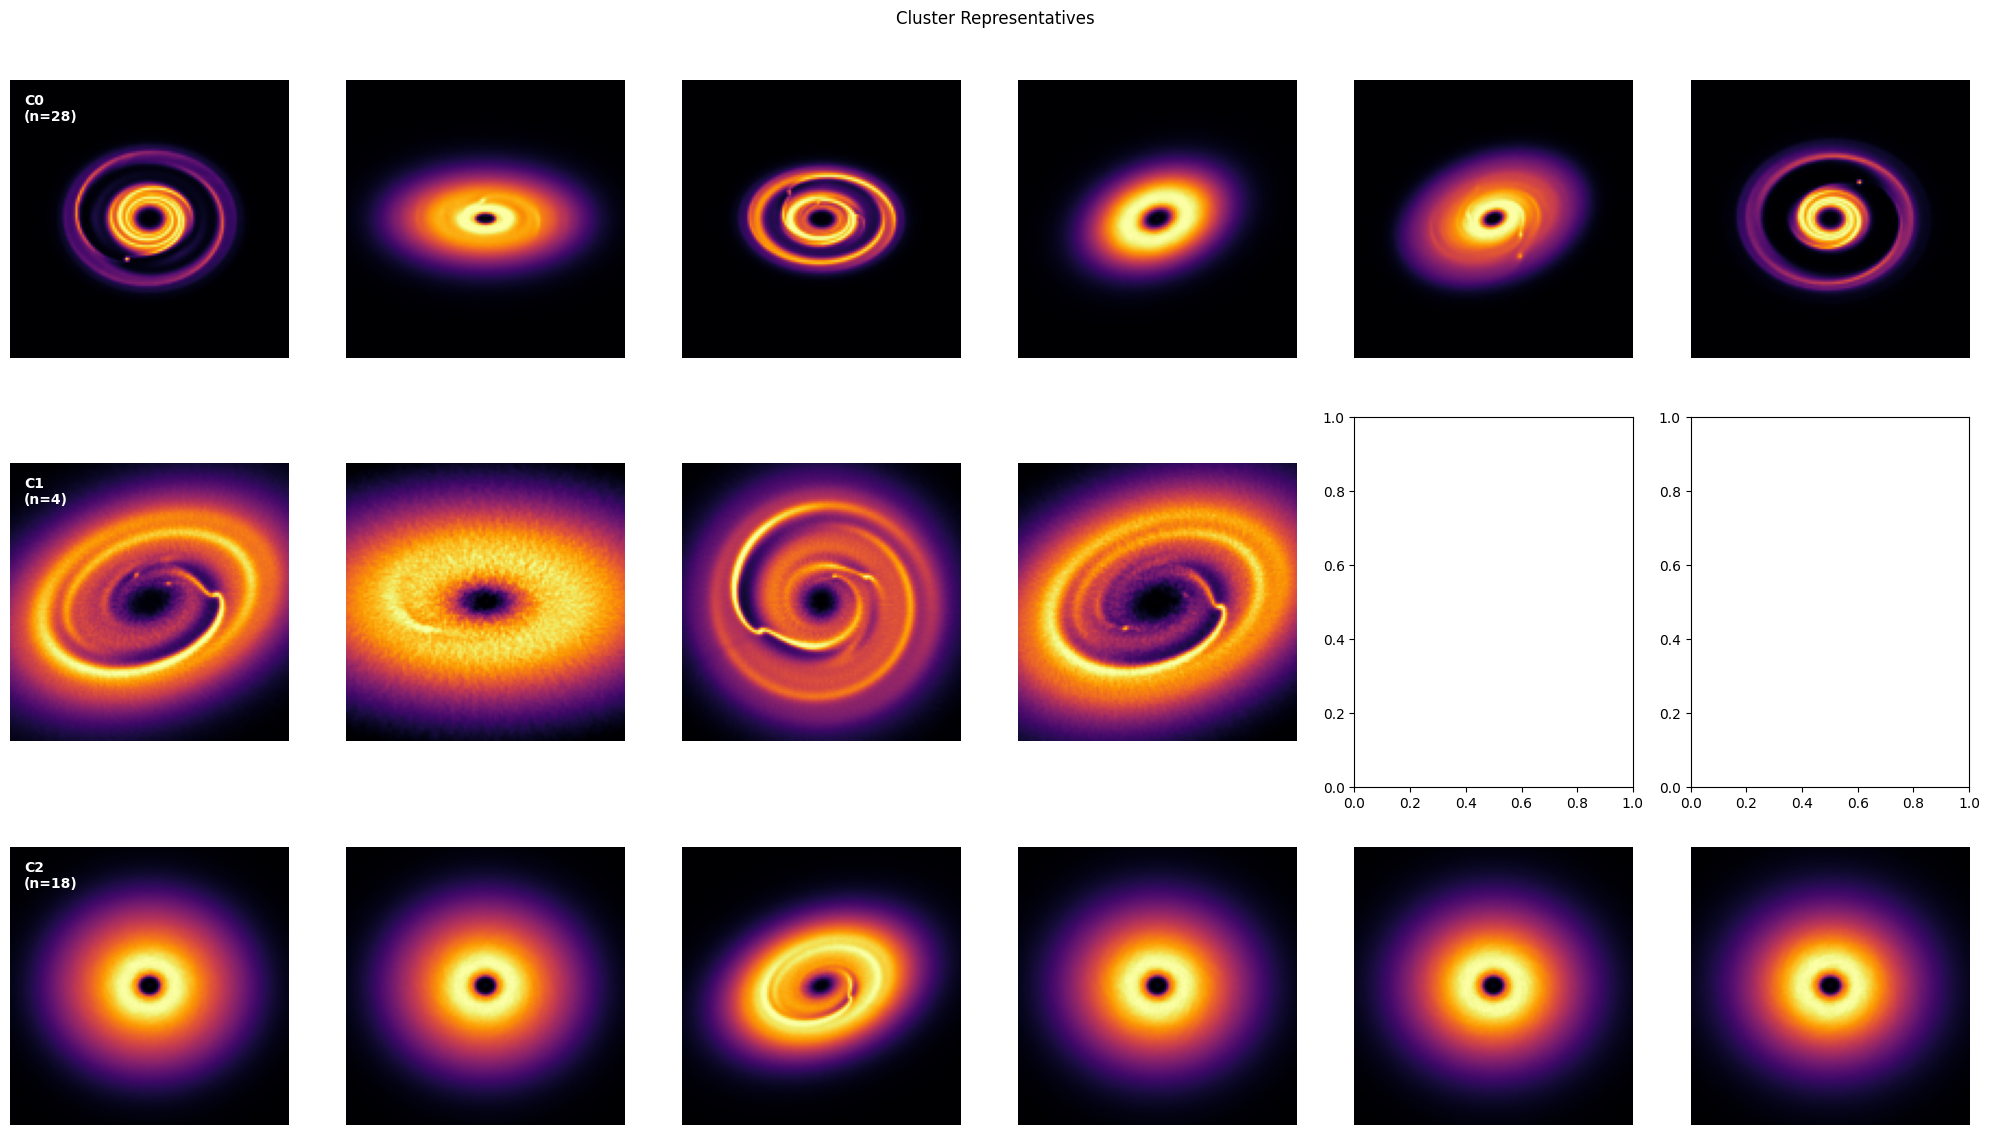

SUMMARY
Disks: 50
Latent dim: 64
Clusters: 3
Silhouette: 0.602
C0: 28
C1: 4
C2: 18


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import umap

# 1. Extract latents
model.eval()
inf_loader = DataLoader(DiskDataset(images), batch_size=32, shuffle=False)
all_z = []
with torch.no_grad():
    for x in inf_loader:
        all_z.append(model.encode(x.to(DEVICE)).cpu().numpy())
latents = np.concatenate(all_z)
latents_s = StandardScaler().fit_transform(latents)
print(f'Latents: {latents.shape}')

# 2. Find optimal K
K_range = range(2,10)
sils = [silhouette_score(latents_s, KMeans(k, n_init=10).fit_predict(latents_s)) for k in K_range]
best_k = K_range[np.argmax(sils)]
print(f'Best K={best_k}, silhouette={max(sils):.3f}')

# 3. Cluster
kmeans = KMeans(best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(latents_s)

# 4. UMAP visualization
reducer = umap.UMAP(random_state=42)
emb2d = reducer.fit_transform(latents_s)

fig, axes = plt.subplots(1,2, figsize=(12,5))
colors = plt.cm.Set1(np.linspace(0,1,best_k))
for c in range(best_k):
    m = labels==c
    axes[0].scatter(emb2d[m,0], emb2d[m,1], c=[colors[c]], s=50, label=f'C{c}({m.sum()})')
axes[0].set_title('UMAP Clusters'); axes[0].legend()
axes[1].scatter(emb2d[:,0], emb2d[:,1], c=labels, cmap='Set1', s=50)
axes[1].set_title('Colored by cluster')
plt.tight_layout(); plt.show()

# 5. Cluster representatives (6 per cluster)
fig, axes = plt.subplots(best_k, 6, figsize=(20, 4*best_k))
for c in range(best_k):
    idx = np.where(labels==c)[0]
    dists = np.linalg.norm(latents_s[idx]-kmeans.cluster_centers_[c], axis=1)
    top6 = idx[np.argsort(dists)[:6]]
    for j, i in enumerate(top6):
        axes[c,j].imshow(images[i], cmap='inferno', origin='lower')
        axes[c,j].axis('off')
        if j==0: axes[c,0].text(0.05, 0.95, f'C{c}\n(n={len(idx)})', transform=axes[c,0].transAxes,
                                va='top', ha='left', fontweight='bold', color='white')
plt.suptitle('Cluster Representatives'); plt.tight_layout(); plt.show()

print('SUMMARY')
print(f'Disks: {len(images)}')
print(f'Latent dim: {latents.shape[1]}')
print(f'Clusters: {best_k}')
print(f'Silhouette: {silhouette_score(latents_s,labels):.3f}')
for c,n in zip(*np.unique(labels,return_counts=True)): print(f'C{c}: {n}')

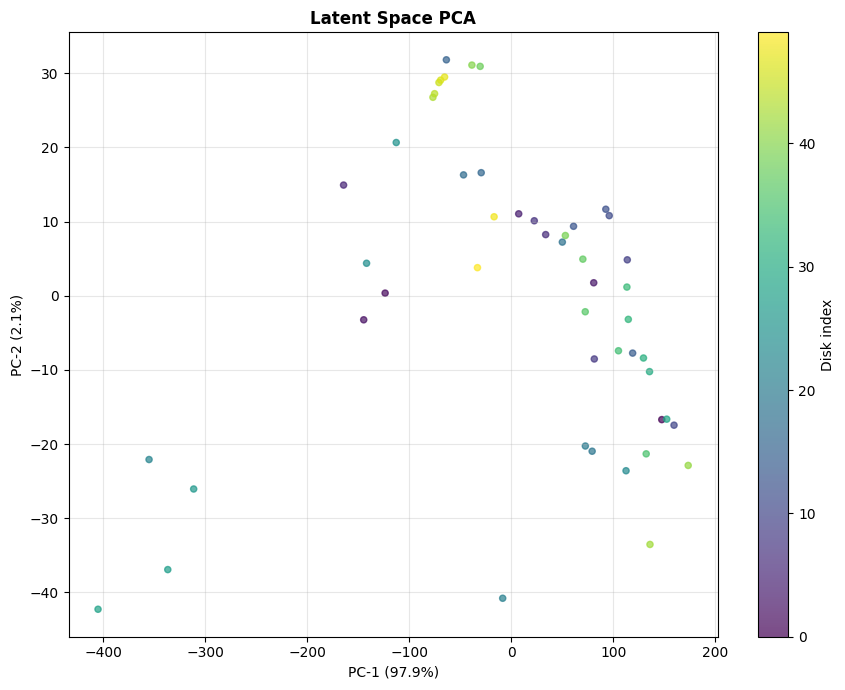

Variance explained: 100.0%


In [13]:
full_loader=DataLoader(DiskDataset(images),batch_size=32,shuffle=False)
all_z=[]
with torch.no_grad():
    for x in full_loader: all_z.append(model.encode(x.to(DEVICE)).cpu().numpy())
all_z=np.concatenate(all_z)

pca=PCA(2,random_state=SEED); z2d=pca.fit_transform(all_z)
fig,ax=plt.subplots(figsize=(9,7))
sc=ax.scatter(z2d[:,0],z2d[:,1],c=np.arange(len(z2d)),cmap='viridis',s=20,alpha=.7)
plt.colorbar(sc,ax=ax,label='Disk index')
ax.set_xlabel(f'PC-1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC-2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Latent Space PCA',fontweight='bold'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('latent_pca.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Variance explained: {sum(pca.explained_variance_ratio_):.1%}')

In [14]:
def run_inference(fits_path, model, device):
    img=preprocess(load_fits(fits_path))
    x=torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        z=model.encode(x); r=model.decode(z)
    mse=nn.functional.mse_loss(r,x).item()
    try: ssim=ms_ssim(r,x,data_range=1.,win_size=7,weights=[.45,.3,.25]).item()
    except: ssim=0.
    return {'latent':z.cpu().numpy(),'recon':r.cpu().numpy(),'mse':mse,'ms_ssim':ssim}

res=run_inference(fits_files[0],model,DEVICE)
print(f'Latent: {res["latent"].shape} | MSE: {res["mse"]:.6f} | MS-SSIM: {res["ms_ssim"]:.4f}')

✓ planet0_00226_1250.fits: (600, 600)
Latent: (1, 64) | MSE: 0.006452 | MS-SSIM: 0.7877


In [16]:
print('='*50)
print('SUMMARY — EXXA Image Test')
print('='*50)
print(f'Architecture : CNN AE + ResBlocks')
print(f'Latent dim   : {model.latent_dim}')
print(f'Image size   : 128x128')
print(f'Epochs       : {EPOCHS}')
print(f'Loss         : 0.2·MSE + 0.8·MS-SSIM')
print(f'Val MSE      : {mean_mse:.6f}')
print(f'Val MS-SSIM  : {mean_ms:.4f}')
print('='*50)
print('Use model.encode(img) to access latent space.')
print('Use run_inference(path, model, device) for new data.')

SUMMARY — EXXA Image Test
Architecture : CNN AE + ResBlocks
Latent dim   : 64
Image size   : 128x128
Epochs       : 60
Loss         : 0.2·MSE + 0.8·MS-SSIM
Val MSE      : 0.033332
Val MS-SSIM  : 0.6941
Use model.encode(img) to access latent space.
Use run_inference(path, model, device) for new data.
